In [2]:
import wget
import torch
import numpy as np 
import os 
os.getcwd()


'c:\\Users\\manpresingh\\OneDrive - Microsoft\\Personal\\PyTorch_and_Advanced NLP\\GPT From Scratch'

In [3]:
with open('input.txt','r', encoding='utf-8') as f:
    text = f.read()

In [5]:
torch.manual_seed(100)

B,T,C = 4,8,2
## 4 Batches (Here we have 1 sentence in each batch)
## 8 words / char / tokens in each sentence
## embedding size of each char / word / token

x = torch.randn(B,T,C)
x, x.shape

(tensor([[[ 0.1268,  1.3564],
          [ 0.5632, -0.1039],
          [-0.3575,  0.3917],
          [-0.6801,  0.2409],
          [ 0.4698,  1.2426],
          [ 0.5403, -1.1454],
          [-1.4592, -1.6281],
          [ 0.3834, -0.1718]],
 
         [[-3.1896,  1.5914],
          [-0.0247, -0.8466],
          [ 0.0293, -0.5721],
          [-1.2546,  0.0486],
          [ 1.1705, -0.5410],
          [-0.7116,  0.0575],
          [ 0.6263, -1.7736],
          [-0.2205,  2.7467]],
 
         [[-1.7599,  1.0230],
          [-0.1107, -0.3899],
          [-1.0300, -1.5446],
          [ 0.5730, -2.0956],
          [-0.1806,  0.2346],
          [-0.1477,  0.5893],
          [ 2.2533, -0.2555],
          [ 0.1651, -0.1629]],
 
         [[-0.8039, -0.9174],
          [ 0.8986,  0.8262],
          [-0.3668, -0.4251],
          [-1.2455,  1.1245],
          [-2.0157,  0.9926],
          [-0.6084, -1.3856],
          [ 1.0412, -0.8043],
          [-0.6244, -0.5882]]]),
 torch.Size([4, 8, 2]))

In [6]:
x[0]
### This represents a sentence with 8 words and each word has embedding size of 2

tensor([[ 0.1268,  1.3564],
        [ 0.5632, -0.1039],
        [-0.3575,  0.3917],
        [-0.6801,  0.2409],
        [ 0.4698,  1.2426],
        [ 0.5403, -1.1454],
        [-1.4592, -1.6281],
        [ 0.3834, -0.1718]])

In [7]:
### The rational behind not working of BigramLM is that when generating t th char/word/token, it only uses t-1 th char/word/token
### So, we need a way to make sure that t-1 th char/word/token has information about all the tokens (0 to t-1 position), so that
### when generating t th token, it uses information of previous tokens (0 to t-1) and generation of the new char/token/word
### is meaningful and in context with the char/words/token generated so far


### So, how do we do this ?
# Ans - Take the average of values till t-1 th token

In [8]:
### The mathematical trick behind self-attention

xbow = torch.zeros((B,T,C))
print(xbow)
 

tensor([[[0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.]]])


In [9]:
xbow[0]

tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])

In [10]:
## Method 1: Take the average as it is using for loop on all sentences and all char/words/token using 2 for loops

### For each batch in B (basically a sentence)
for b in range(B):
    
    ### For char/word/token in T
    for t in range(T):
        
        ## Take the char/word/token and keep taking the average till t th char/word/token
        xprev = x[b,:t+1] ## t,C
        xbow[b,t]= torch.mean(xprev,0)

In [11]:
xbow[0]

tensor([[ 0.1268,  1.3564],
        [ 0.3450,  0.6262],
        [ 0.1109,  0.5481],
        [-0.0869,  0.4713],
        [ 0.0245,  0.6256],
        [ 0.1104,  0.3304],
        [-0.1138,  0.0506],
        [-0.0517,  0.0228]])

In [12]:
x[0]

tensor([[ 0.1268,  1.3564],
        [ 0.5632, -0.1039],
        [-0.3575,  0.3917],
        [-0.6801,  0.2409],
        [ 0.4698,  1.2426],
        [ 0.5403, -1.1454],
        [-1.4592, -1.6281],
        [ 0.3834, -0.1718]])

In [13]:
### This is how updated xbow (as calculated and showm above) has been calculated using for loop
### This represents that t th word/char/token has average of all the previous words/chars/tokens
(x[0][1] + x[0][0])/2, (x[0][2]+ x[0][1] + x[0][0])/3, (x[0][3]+x[0][2]+ x[0][1] + x[0][0])/4  
### and so on

(tensor([0.3450, 0.6262]),
 tensor([0.1109, 0.5481]),
 tensor([-0.0869,  0.4713]))

In [ ]:
### Method 2: Now, "The Trick" -> the above method is very inefficient and we can do the same thing using matrix multiplication

In [14]:
wei = torch.tril(torch.ones(T,T))
wei

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])

In [15]:
wei = wei/ wei.sum(1, keepdim=True)
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [ ]:
### Note: (T,T) @ (B,T,C) -> (B,T,C) , In this case it is actually a matrix multiplication of (T,T) @ (T,C) applied to all the B batches
xbow2 = wei @ x 
xbow2

tensor([[[ 0.1268,  1.3564],
         [ 0.3450,  0.6262],
         [ 0.1109,  0.5481],
         [-0.0869,  0.4713],
         [ 0.0245,  0.6256],
         [ 0.1104,  0.3304],
         [-0.1138,  0.0506],
         [-0.0517,  0.0228]],

        [[-3.1896,  1.5914],
         [-1.6072,  0.3724],
         [-1.0617,  0.0576],
         [-1.1099,  0.0553],
         [-0.6538, -0.0639],
         [-0.6635, -0.0437],
         [-0.4792, -0.2908],
         [-0.4469,  0.0889]],

        [[-1.7599,  1.0230],
         [-0.9353,  0.3166],
         [-0.9669, -0.3038],
         [-0.5819, -0.7518],
         [-0.5016, -0.5545],
         [-0.4427, -0.3639],
         [-0.0575, -0.3484],
         [-0.0297, -0.3252]],

        [[-0.8039, -0.9174],
         [ 0.0473, -0.0456],
         [-0.0907, -0.1721],
         [-0.3794,  0.1521],
         [-0.7067,  0.3202],
         [-0.6903,  0.0359],
         [-0.4429, -0.0842],
         [-0.4656, -0.1472]]])

In [17]:
torch.allclose(xbow, xbow2)

True

In [18]:
x[0], wei, xbow2[0]

(tensor([[ 0.1268,  1.3564],
         [ 0.5632, -0.1039],
         [-0.3575,  0.3917],
         [-0.6801,  0.2409],
         [ 0.4698,  1.2426],
         [ 0.5403, -1.1454],
         [-1.4592, -1.6281],
         [ 0.3834, -0.1718]]),
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
         [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
         [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
         [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]]),
 tensor([[ 0.1268,  1.3564],
         [ 0.3450,  0.6262],
         [ 0.1109,  0.5481],
         [-0.0869,  0.4713],
         [ 0.0245,  0.6256],
         [ 0.1104, 

In [19]:
wei[1]@ x[0]

tensor([0.3450, 0.6262])

In [33]:
## Method 3 using Softmax (This is the real method which has been implemented in transoformers / GPT models)

tril = torch.tril(torch.ones(T,T))
print(f"tril:\n {tril}")
wei = torch.zeros((T,T))
print(f"wei: \n{wei}")

tril:
 tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
wei: 
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [34]:
wei = wei.masked_fill(tril==0, float('-inf'))
wei

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [35]:
import torch.nn.functional as F

In [36]:
wei = F.softmax(wei, dim=-1)
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [38]:
xbow3 = wei @ x
xbow3

tensor([[[ 0.1268,  1.3564],
         [ 0.3450,  0.6262],
         [ 0.1109,  0.5481],
         [-0.0869,  0.4713],
         [ 0.0245,  0.6256],
         [ 0.1104,  0.3304],
         [-0.1138,  0.0506],
         [-0.0517,  0.0228]],

        [[-3.1896,  1.5914],
         [-1.6072,  0.3724],
         [-1.0617,  0.0576],
         [-1.1099,  0.0553],
         [-0.6538, -0.0639],
         [-0.6635, -0.0437],
         [-0.4792, -0.2908],
         [-0.4469,  0.0889]],

        [[-1.7599,  1.0230],
         [-0.9353,  0.3166],
         [-0.9669, -0.3038],
         [-0.5819, -0.7518],
         [-0.5016, -0.5545],
         [-0.4427, -0.3639],
         [-0.0575, -0.3484],
         [-0.0297, -0.3252]],

        [[-0.8039, -0.9174],
         [ 0.0473, -0.0456],
         [-0.0907, -0.1721],
         [-0.3794,  0.1521],
         [-0.7067,  0.3202],
         [-0.6903,  0.0359],
         [-0.4429, -0.0842],
         [-0.4656, -0.1472]]])

In [39]:
x[0], wei, xbow3[0]

(tensor([[ 0.1268,  1.3564],
         [ 0.5632, -0.1039],
         [-0.3575,  0.3917],
         [-0.6801,  0.2409],
         [ 0.4698,  1.2426],
         [ 0.5403, -1.1454],
         [-1.4592, -1.6281],
         [ 0.3834, -0.1718]]),
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
         [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
         [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
         [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]]),
 tensor([[ 0.1268,  1.3564],
         [ 0.3450,  0.6262],
         [ 0.1109,  0.5481],
         [-0.0869,  0.4713],
         [ 0.0245,  0.6256],
         [ 0.1104, 

In [40]:
wei[1]@ x[0]

tensor([0.3450, 0.6262])

In [ ]:
### Method 4: A small self-attention block:

## What we have seen so far is that wei elements are uniformly distirbuted, which tells that equal weightage will be given to all the 0 to t-1 chars/words/tokens when generating t the token
## However, this is not right because each word/char/token has a different relation with other word/char/token and we want this relation to be data dependent
## example when generating t th token, 2nd and 4th token maybe more important than 1st token, and we want this information to flow to t th token creation
## This is where self-attention solves the problem for us
## Every single token/char/word at each position will omit 2 vectors ->> query vector and key vector
## So, query * key tells us what is the importance among different word/char/tokens as per the input data

### Query:  This matrix represents the focus word for which the context is being determined. By transforming the word representation using the query matrix, 
###         the system generates a query vector that will be used to compare against other words in the sentence 

### key:    The key matrix is used to create key vectors for all words in the sentence. These key vectors help the system measure the relevance or similarity between the focus 
###         word (using the query vector) and other words in the sentence. A higher similarity score between the query vector and a key vector indicates a stronger relationship 
###         between the corresponding words.

## So, now, wei is calcualated using query and key vectors

torch.manual_seed(100)

B,T,C = 4,8,12
x = torch.randn(B,T,C)
head_size = 6
query = torch.nn.Linear(C, head_size, bias=False)
key = torch.nn.Linear(C, head_size, bias=False)

k = key(x)
q = query(x)

In [100]:
k.shape, q.shape
### B,T, head_size

(torch.Size([4, 8, 6]), torch.Size([4, 8, 6]))

In [101]:
key, query

(Linear(in_features=12, out_features=6, bias=False),
 Linear(in_features=12, out_features=6, bias=False))

In [102]:
wei = q @ k.transpose(-2,-1) ### This means (B,T,head_size) @ (B,head_size,T) -> (B,T,T)
wei.shape, wei

(torch.Size([4, 8, 8]),
 tensor([[[-1.1408e-02, -1.0538e-01, -6.4523e-01, -4.8978e-01, -2.3253e-01,
           -9.1046e-02, -4.2085e-01,  2.4386e-01],
          [ 1.0391e-01,  6.0440e-01, -2.7030e-01, -1.7505e-01,  6.9258e-01,
           -2.9533e-01,  6.4535e-01, -1.2700e+00],
          [-1.2411e-01, -4.6818e-01, -1.0699e+00, -5.9801e-01, -6.5395e-01,
           -1.2325e-01, -4.3271e-01,  4.8278e-01],
          [ 3.6238e-02,  1.3749e+00,  2.7533e-01,  1.0094e+00,  1.3117e-03,
           -3.2594e-01,  6.8664e-01,  1.0301e-01],
          [ 6.6059e-01, -2.4674e+00, -1.0726e+00, -1.6657e+00, -8.7125e-01,
           -2.1342e-01, -9.6375e-01,  3.1733e-02],
          [ 2.3698e-02, -1.9374e-01,  3.6680e-01,  2.7381e-01, -8.1063e-02,
            1.2161e-01,  1.0981e-01,  1.8389e-01],
          [ 7.1039e-01, -1.6418e+00, -1.2807e+00, -1.2866e+00, -1.7564e+00,
           -8.7114e-01, -1.7173e+00,  9.1441e-01],
          [-6.4350e-01,  2.0969e+00, -1.0280e+00,  5.0239e-01, -3.9918e-01,
           

In [103]:
tril = torch.tril(torch.ones((T,T)))
# wei = torch.zeros((T,T))
wei = wei.masked_fill(tril==0, float('-inf'))
wei = F.softmax(wei,dim=-1)
wei

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3774, 0.6226, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4768, 0.3380, 0.1852, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1145, 0.4369, 0.1455, 0.3031, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.6518, 0.0286, 0.1152, 0.0636, 0.1409, 0.0000, 0.0000, 0.0000],
         [0.1538, 0.1238, 0.2168, 0.1975, 0.1385, 0.1696, 0.0000, 0.0000],
         [0.5727, 0.0545, 0.0782, 0.0777, 0.0486, 0.1178, 0.0505, 0.0000],
         [0.0369, 0.5715, 0.0251, 0.1160, 0.0471, 0.0367, 0.0687, 0.0981]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5840, 0.4160, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0172, 0.7116, 0.2712, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1172, 0.3347, 0.0616, 0.4865, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2141, 0.1792, 0.4902, 0.0390, 0.0774, 0.0000, 0.0000, 0.0000],
         [0.0434, 0.248

In [104]:
wei.shape, x.shape

(torch.Size([4, 8, 8]), torch.Size([4, 8, 12]))

In [105]:
out =wei @ x ### B,T,T and B,T,C  -> B,T,C
out.shape, out

(torch.Size([4, 8, 12]),
 tensor([[[ 1.2685e-01,  1.3564e+00,  5.6322e-01, -1.0393e-01, -3.5746e-01,
            3.9174e-01, -6.8009e-01,  2.4094e-01,  4.6981e-01,  1.2426e+00,
            5.4030e-01, -1.1454e+00],
          [-8.6061e-01, -5.0167e-01,  4.5125e-01, -1.4618e-01, -2.1207e+00,
            1.1386e+00, -2.7204e-01, -4.3614e-01,  1.9556e-01,  1.1284e-01,
           -5.7718e-01, -4.0205e-01],
          [-2.1598e-01, -3.7404e-03,  2.6636e-01, -9.6971e-02, -1.1326e+00,
            3.9626e-01, -3.7345e-01,  3.3738e-01, -9.1993e-02,  5.8858e-01,
           -1.8695e-01, -6.0192e-01],
          [-7.6489e-01, -1.1028e+00,  3.0215e-01, -7.1382e-01, -1.3980e+00,
            5.5321e-01, -1.6554e-01,  2.3595e-01,  4.9361e-01, -3.6200e-02,
           -4.5226e-01, -2.1606e-01],
          [-2.9769e-03,  5.4770e-01,  4.5912e-01, -8.3004e-02, -3.1507e-01,
            5.1541e-02, -6.5421e-01,  6.4512e-01, -3.6197e-02,  1.0349e+00,
            2.2837e-01, -9.9562e-01],
          [-4.5532e-02, -

In [106]:
x[0], wei[0], out[0]


(tensor([[ 0.1268,  1.3564,  0.5632, -0.1039, -0.3575,  0.3917, -0.6801,  0.2409,
           0.4698,  1.2426,  0.5403, -1.1454],
         [-1.4592, -1.6281,  0.3834, -0.1718, -3.1896,  1.5914, -0.0247, -0.8466,
           0.0293, -0.5721, -1.2546,  0.0486],
         [ 1.1705, -0.5410, -0.7116,  0.0575,  0.6263, -1.7736, -0.2205,  2.7467,
          -1.7599,  1.0230, -0.1107, -0.3899],
         [-1.0300, -1.5446,  0.5730, -2.0956, -0.1806,  0.2346, -0.1477,  0.5893,
           2.2533, -0.2555,  0.1651, -0.1629],
         [-0.8039, -0.9174,  0.8986,  0.8262, -0.3668, -0.4251, -1.2455,  1.1245,
          -2.0157,  0.9926, -0.6084, -1.3856],
         [ 1.0412, -0.8043, -0.6244, -0.5882,  1.6700, -0.9275, -0.9759,  1.3312,
           0.9007, -0.6585, -0.9327, -1.5749],
         [ 1.4861, -1.4092,  1.4330,  0.3899, -0.1152, -0.2361, -2.2235,  0.0788,
           0.0416,  1.2813, -0.8262,  0.0231],
         [ 1.9301,  0.7803,  0.3180, -0.6992, -0.3921,  2.1955,  0.3312,  0.1417,
          -1.52

**Explaination**:

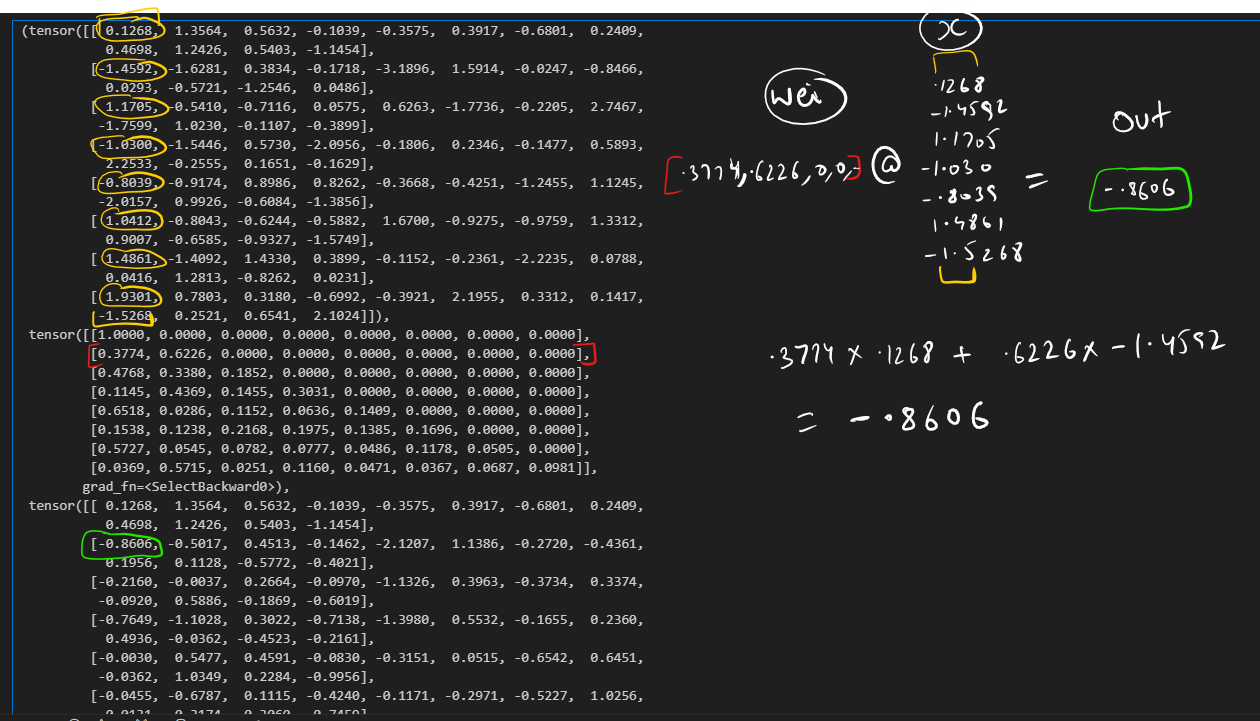

In [ ]:
### Introduction of value vector V and its importance:
## Value:  The value matrix generates value vectors for all words in the sentence. These vectors hold the contextual information of each word.
##         Generally, we pass input x through a linear layer to get vector v such that the represenation of each word improves and becomes richer in vector v

## Role of V: Information Transfer (Weighted Content)
### The Value (V) vector, on the other hand, represents the actual information content of the word, which we want to pass to the next layer.
### After calculating the attention score between words, we use this score to scale (weight) the V vector. This weighted value tells the model which parts of each word’s 
### content should be highlighted based on its relevance.
### For example, if "the" and "cat" have a high attention score, we use this score to amplify or de-emphasize "cat’s" value vector in the context of "the."

## Why is it important?
### 1. If we directly applied QK attention scores to the input 𝑋 (original input features) without separating V, we would be trying to mix two purposes—relevance 
### weighting and content representation—in the same space, which could create several issues

## 2. Also, input X givs a raw embedding which may have same meaning of the word in different context but with vector v, it allows us to capture different 
## meaning of the word in different context



In [113]:
import math

In [ ]:
torch.manual_seed(100)

B,T,C = 4,8,32
x = torch.randn(B,T,C)
head_size = 64
query = torch.nn.Linear(C, head_size, bias=False)
key = torch.nn.Linear(C, head_size, bias=False)
value = torch.nn.Linear(C,head_size, bias=False)

k = key(x)
q = query(x)
v = value(x)

wei = q @ k.transpose(-2,-1) ### This means (B,T,head_size) @ (B,head_size,T) -> (B,T,T)

wei = wei / math.sqrt(head_size)  
## This is needed to make sure that softmax doesn't make the high positibve values of wei too high i.e make them too sharp especially in the initialization phase
## This will make the output dependent and focus on these sharp values. ie. to reduce the variance of the wei matrix
## See Example 1 below

tril = torch.tril((torch.ones(T,T)))
wei = wei.masked_fill(tril==0, float('-inf')) 
### In encoder blocks we delete this line of code as we want future char/word/token to talk and get attention from past word/char/tokens
## example: BERT model

wei = F.softmax(wei, dim=-1)
# The dim=-1 ensures that each row in the tensor is treated independently, and the softmax values are computed for the elements within that row

out = wei @ v
out.shape, out

(torch.Size([4, 8, 64]),
 tensor([[[ 4.9073e-02, -3.7379e-01, -8.5984e-01,  ..., -3.2280e-01,
           -3.7366e-01, -5.5954e-02],
          [-4.9525e-01, -5.8582e-01, -5.5149e-01,  ..., -1.1347e+00,
           -6.7635e-04, -1.3969e-02],
          [-3.1672e-01, -3.7236e-01, -6.0112e-01,  ..., -4.9383e-01,
           -6.3075e-02, -9.6308e-03],
          ...,
          [-7.9035e-02, -1.9363e-01, -2.1680e-01,  ..., -4.7210e-01,
           -8.5018e-02,  6.3129e-02],
          [ 9.0481e-02, -1.2571e-01, -1.9909e-01,  ..., -3.2032e-01,
           -1.0788e-01,  2.4123e-02],
          [ 6.7148e-02, -1.6216e-01, -2.5975e-03,  ..., -3.0388e-01,
           -1.3433e-01,  6.3878e-02]],
 
         [[-7.7588e-01,  7.8466e-01,  1.9359e-01,  ..., -4.8805e-01,
            8.1017e-01, -7.7282e-03],
          [-6.4391e-02,  2.2036e-01,  4.2865e-01,  ..., -5.0981e-01,
           -1.9804e-01,  3.4529e-01],
          [-4.5872e-01,  6.1760e-02,  3.1299e-01,  ..., -1.2576e-01,
            1.2372e-01, -1.0854e

In [145]:
k.shape, q.shape, v.shape

(torch.Size([4, 8, 64]), torch.Size([4, 8, 64]), torch.Size([4, 8, 64]))

In [147]:
wei.shape, out.shape, x.shape

(torch.Size([4, 8, 8]), torch.Size([4, 8, 64]), torch.Size([4, 8, 32]))

In [127]:
k.var(), q.var(), (q @ k.transpose(-2,-1)).var(),  ((q @ k.transpose(-2,-1))/(math.sqrt(head_size))).var()

(tensor(0.3074, grad_fn=<VarBackward0>),
 tensor(0.3085, grad_fn=<VarBackward0>),
 tensor(5.0441, grad_fn=<VarBackward0>),
 tensor(0.0788, grad_fn=<VarBackward0>))

In [ ]:
## Example 1:
print(torch.softmax(torch.tensor([.1,-.2, .3, 2, 5, -.5, 2, 1]), dim=-1))
## You can see the 4th value resulted in .8741 after softmax


## now, let's see that if we divide by head_size sqrt, the values are somehat less sharp towards high values
print(torch.softmax(torch.tensor([.1,-.2, .3, 2, 5, -.5, 2, 1])/math.sqrt(head_size), dim=-1))

tensor([0.0065, 0.0048, 0.0080, 0.0435, 0.8741, 0.0036, 0.0435, 0.0160])
tensor([0.1062, 0.1023, 0.1089, 0.1347, 0.1959, 0.0985, 0.1347, 0.1188])


In [111]:
## now, we pass this output to a lienar layer again to make the shape back to C

mylayer = torch.nn.Linear(head_size,C, bias=False)

final_output = mylayer(out)

In [112]:
final_output.shape, x.shape

(torch.Size([4, 8, 32]), torch.Size([4, 8, 32]))

In [ ]:
## NOTE: what is cross-attention: It's a concept in encoder-decoder architecture where Q comes from decoder and K,V comes from encoder

### Data Pre-Processing

In [177]:
with open('input.txt','r', encoding='utf-8') as f:
    text = f.read()

In [178]:
chars = sorted(list((set(text))))
vocab_size = len(chars)
print("".join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [179]:
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}


In [180]:
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: [itos[i] for i in l]


In [181]:
data = torch.tensor(encode(text), dtype=torch.long)

In [182]:
n = int(len(data)*.9)
print(n)

train_data = data[0:n]
val_data = data[n:]

1003854


### Version 1 of GPTLM using Self-Attention Block

In [3]:
import torch.nn as nn
import torch

In [4]:
batch_size = 64 ## How many independent sequences (sentences) will we process in parallel
block_size = 256 ## what is maximum context length for prediction ? i.e max input sentence length in terms of tokens (like BERT has 512)
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
device ='cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384
n_head = 6
n_layers = 6
dropout = .2

In [6]:
n_embd/n_head

64.0

In [187]:
def get_batch(split):
     data = train_data if split=='train' else val_data
     ix = torch.randint(len(data)-block_size,(batch_size,))
     x = torch.stack([data[i:i+block_size] for i in ix])
     y = torch.stack([data[i+1:i+block_size+1] for i in ix])
     return x, y, ix

In [188]:
### Let's build the Self-attention and GPTLM modules:

class Head(nn.Module):
    """ One head of self-attention """
    
    def __init__(self, head_size):
        super().__init__()
        self.key= nn.Linear(n_embd, head_size, bias=False)
        self.query= nn.Linear(n_embd, head_size, bias=False)
        self.value= nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        
        wei = (q@ k.transpose(-2,-1)) / (math.sqrt(C)) ## (B,T,C) @ (B,C,T) -> (B,T,T)
        wei = wei.masked_fill(self.tril[:T,:T]==0, float('-inf')) ## B,T,T  ### FYI: This step is for decoder only arch. When implementing BERT, remove this step and code will work as is
        wei = F.softmax(wei, dim=-1) # B,T,T
        wei = self.dropout(wei)
        v = self.value(x)
        out = wei @ v ## (B,T,T) , (B,T,C) -> (B,T,C)
        return out
    

In [189]:
nn.Embedding(block_size, n_embd),nn.Embedding(block_size, n_embd)(torch.arange(256, device=device)).shape, torch.arange(256, device=device).shape

(Embedding(256, 384), torch.Size([256, 384]), torch.Size([256]))

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout) 
        
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1) ## This is generating independent Q,K,V for each head rather than using single Q,K,V and split-head.
        out = self.dropout(self.proj(out))
        # out = self.proj(out)
        return out

**IMPORTANT**
* NOTE: In the MultiHeadAttention class above, we can see the there is no split head function, rather same "x" is being used n_heads times for each head. This leads to creating indpendent
Q,K,V for each i.e. Same x is used n_heads times and passed through Head to created independent Q,K,V. 
* However, in the original paper, it was shown that we need single Q,K,V and split it across n_heads. This way there are only 1 set of Q,K,V per head and multiple independent Q,K,V for each head

### Details:
The concept of **independent \( Q, K, V \)** versus **shared \( Q, K, V \)** in multi-head attention refers to how the query, key, and value vectors are calculated for each head in the multi-head attention mechanism.

Here’s a detailed comparison:

---

### **Shared \( Q, K, V \) Approach**
This is the **standard implementation** and aligns with the original Transformer paper.

1. **Process**:
   - A single set of \( Q, K, V \) matrices is computed for the entire input using shared linear transformations.
   - These matrices are split into \( h \) smaller parts, where \( h \) is the number of heads.
   - Each part corresponds to one head and works independently on its respective chunk of the data.

   **Formula**:
   - Shared:
     \[
     Q = XW_q, \quad K = XW_k, \quad V = XW_v
     \]
   - Split for heads:
     \[
     Q_h = \text{split}(Q), \quad K_h = \text{split}(K), \quad V_h = \text{split}(V)
     \]

2. **Advantages**:
   - **Efficient**: Only one set of \( Q, K, V \) matrices is computed, reducing memory and computational costs.
   - **Aligned with Paper**: This approach is consistent with the original Transformer design.
   - **Less Redundant**: Reuses the same \( Q, K, V \) across all heads.

3. **Disadvantages**:
   - **Shared Transformations**: All heads use the same learned linear transformation, potentially limiting head diversity.

---

### **Independent \( Q, K, V \) Approach**
In this approach, each head computes its own independent \( Q, K, V \) matrices with separate learnable parameters.

1. **Process**:
   - Each head has its own linear layers to compute \( Q, K, V \).
   - No splitting is required because each head generates its \( Q, K, V \) independently.

   **Formula**:
   - Independent:
     \[
     Q_h = XW_{q,h}, \quad K_h = XW_{k,h}, \quad V_h = XW_{v,h}
     \]
   - Here, \( W_{q,h}, W_{k,h}, W_{v,h} \) are separate learnable parameters for each head.

2. **Advantages**:
   - **Increased Flexibility**: Each head has its own set of parameters, allowing for more diverse learning.
   - **Potential for Specialization**: Heads can learn more specialized representations.

3. **Disadvantages**:
   - **Higher Computational Cost**: More parameters and computations are required.
   - **Memory Usage**: Requires more memory for the additional parameters.

---

### **Comparison Table**

| Aspect                   | Shared \( Q, K, V \)                    | Independent \( Q, K, V \)             |
|--------------------------|-----------------------------------------|---------------------------------------|
| **Parameter Sharing**    | Single set of \( W_q, W_k, W_v \) shared | Separate \( W_q, W_k, W_v \) for each head |
| **Computation**          | Compute \( Q, K, V \) once, split among heads | Compute \( Q, K, V \) separately for each head |
| **Efficiency**           | High                                   | Lower (more parameters, computations) |
| **Flexibility**          | Moderate (all heads share transforms)  | High (each head is independent)       |
| **Memory Usage**         | Lower                                  | Higher                                |
| **Use Case**             | Standard in Transformer architecture   | Rare; may be used for experimental designs |

---

### **Code Example**
Here’s an illustration using PyTorch:

#### Shared \( Q, K, V \):
```python
import torch
import torch.nn as nn

class SharedQKV(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv_proj = nn.Linear(embed_dim, 3 * embed_dim)  # Shared projection
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv_proj(x)  # Single shared projection
        q, k, v = qkv.split(C, dim=-1)  # Split into Q, K, V
        q, k, v = [t.reshape(B, T, self.num_heads, self.head_dim).transpose(1, 2) for t in (q, k, v)]
        # Compute attention...
        return self.out_proj(q)  # Merge heads back
```

#### Independent \( Q, K, V \):
```python
class IndependentQKV(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.q_projs = nn.ModuleList([nn.Linear(embed_dim, self.head_dim) for _ in range(num_heads)])
        self.k_projs = nn.ModuleList([nn.Linear(embed_dim, self.head_dim) for _ in range(num_heads)])
        self.v_projs = nn.ModuleList([nn.Linear(embed_dim, self.head_dim) for _ in range(num_heads)])
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = [], [], []
        for i in range(self.num_heads):
            q.append(self.q_projs[i](x))
            k.append(self.k_projs[i](x))
            v.append(self.v_projs[i](x))
        # Concatenate heads
        q, k, v = [torch.stack(t, dim=1) for t in (q, k, v)]
        # Compute attention...
        return self.out_proj(q)  # Merge heads back
```

---

### **When to Use Which?**
1. **Shared \( Q, K, V \):**
   - Preferred for most standard applications.
   - Efficient and follows the original Transformer design.

2. **Independent \( Q, K, V \):**
   - Useful if head specialization is critical.
   - May benefit tasks requiring highly diverse head representations.

In [197]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
                                 nn.Linear(n_embd, 4*n_embd), 
                                 nn.ReLU(),
                                 nn.Linear(4*n_embd, n_embd),
                                 nn.Dropout(dropout),
                                 ) ### This last nn.Linear is the project layer  (What is this here ?)

    def forward(self, x):
        return self.net(x)

**BatchNorm v/s LayerNorm**
- Check my word file notes

In [199]:
class  Block(nn.Module):
    
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        
    def forward(self,x):
        ### here we are not implementing add & norm but we implementing norm then attention then add
        ### this is different from original transformer paper as it was found out later that adding norm before self-attention is more beneficial
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x
        

In [ ]:
class GPTLanguageModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) ## For each word's embedding value, we have a position embedding value
        
        ### v1
        # self.sa_head = Head(n_embd)
        
        ### v2
        # self.sa_heads = MultiHeadAttention(4, n_embd//4)
        # self.ffwd = FeedForward(n_embd)
        
        ### v3
        # self.blocks = nn.Sequential(Block(n_embd, n_head=4),
        #                             Block(n_embd, n_head=4),
        #                             Block(n_embd, n_head=4),
        #                             nn.LayerNorm(n_embd))
        
        ### v4
        self.blocks = nn.Sequential(*[Block(n_embd,n_head=n_head) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(n_embd)
        
        self.lm_head = nn.Linear(n_embd, vocab_size)
    
    def forward(self, idx, targets=None):
        B,T = idx.shape
        
        self.tok_emb = self.token_embedding_table(idx) ## Now, it is B,T,C
        self.pos_emb = self.position_embedding_table(torch.arange(T, device=device)) ## T,C
        self.x = self.tok_emb + self.pos_emb ## B,T,C
        
        # self.x2 = self.sa_head(self.x)
        # self.x3 = self.ffwd(self.x2)
        
        self.x2 = self.blocks(self.x)
        self.x3 = self.ln_f(self.x2)
        
        
        self.logits = self.lm_head(self.x3)
        
        if targets is None:
            loss = None
        else:
            B,T,C = self.logits.shape
            self.logits = self.logits.view(B*T,C)
            targets = targets.view(B*T)
            self.loss = F.cross_entropy(self.logits, targets)
        
        return self.logits, self.loss
    
    
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            
            idx_cond = idx[:, - block_size:]
            ### This takes the entire sentence upto block sentence to generate next token
            
            logits, loss = self(idx_cond)
            
            logits = logits[:,-1,:]
            
            probs = F.softmax(logits, dim=-1)
            
            idx_next = torch.multinomial(probs, num_samples=1)
            ### is a function in PyTorch that is used to sample elements from a tensor based on a given probability distribution. 
            ### It is typically used for tasks like sampling from a probability distribution or simulating stochastic processes
            ## Example:
                    # import torch
                    # # Probability distribution
                    # weights = torch.tensor([0.1, 0.3, 0.4, 0.2])
                    # # Sample 2 elements without replacement
                    # samples = torch.multinomial(weights, num_samples=2, replacement=False)
                    # print(samples)

            idx = torch.cat((idx, idx_next), dim=1) ## For 2D tensors, dim=1 and dim=-1 yield the same result.
            ### Now, the newly generated token is added to the existing input sentence and this new sentence (input and generated token) 
            ### will be used as an input to generate next token, and so on
        return idx
    
        
        

In [262]:
model = GPTLanguageModel()

In [263]:
model

GPTLanguageModel(
  (token_embedding_table): Embedding(65, 384)
  (position_embedding_table): Embedding(256, 384)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-5): 6 x Head(
            (key): Linear(in_features=384, out_features=64, bias=False)
            (query): Linear(in_features=384, out_features=64, bias=False)
            (value): Linear(in_features=384, out_features=64, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((384,), eps=1e-05, elementwise_affine

In [264]:
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

10.788929 M parameters


In [267]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [268]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters//10)
        for k in range(eval_iters//10):
            X, Y,ix = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [269]:
max_iters//10, eval_interval//10

(500, 50)

In [270]:
from datetime import datetime

In [271]:
over_all_start_time = datetime.now()
for iter in range(max_iters//10):
    if iter%10==0:  
      start_time = datetime.now()
      print(f"Epoch: {iter} started @ {start_time}")
     
    # every once in a while evaluate the loss on train and val sets
    if iter % (eval_interval//10) == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb, ix = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if iter%10==0:
      end_time = datetime.now()
      print(f"Epoch: {iter} completed @ {end_time} in {end_time-start_time} seconds with loss -> {loss}\n")

over_all_end_time = datetime.now()
print(f"Total time to run {max_iters//10} is {over_all_end_time - over_all_start_time} seconds")    

Epoch: 0 started @ 2024-11-12 21:07:08.933744
step 0: train loss 4.3143, val loss 4.3170
Epoch: 0 completed @ 2024-11-12 21:10:33.685364 in 0:03:24.751620 seconds with loss -> 4.310461521148682

Epoch: 10 started @ 2024-11-12 21:12:32.880813
Epoch: 10 completed @ 2024-11-12 21:12:48.691020 in 0:00:15.810207 seconds with loss -> 2.999790668487549

Epoch: 20 started @ 2024-11-12 21:14:48.381032
Epoch: 20 completed @ 2024-11-12 21:15:06.883203 in 0:00:18.502171 seconds with loss -> 2.805706739425659

Epoch: 30 started @ 2024-11-12 21:17:04.003763
Epoch: 30 completed @ 2024-11-12 21:17:16.105721 in 0:00:12.101958 seconds with loss -> 2.6918179988861084

Epoch: 40 started @ 2024-11-12 21:18:59.142730
Epoch: 40 completed @ 2024-11-12 21:19:10.525914 in 0:00:11.383184 seconds with loss -> 2.5974466800689697

Epoch: 50 started @ 2024-11-12 21:20:49.177574
step 50: train loss 2.5548, val loss 2.5625
Epoch: 50 completed @ 2024-11-12 21:24:13.839893 in 0:03:24.662319 seconds with loss -> 2.570369

In [272]:
len(xb[0])

256

In [273]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
ans = decode(model.generate(context, max_new_tokens=500)[0].tolist())
### with 500 epochs training

In [274]:
"".join(ans)

"\nWIA fil, the mang thaplo-dd ith you do und\nGod Aspel fent noth gon be; ancteres!\nO Candme coind If you sldsi;\nI suee mis, nod as asare'de, s knobrte's? loser Bod anisfes\nTh uctif see'tll, thavel by fuedd sisecy ut I tlomWinghe!\nQUER; WAn, otk sardverownd covone harow thy it.\nO RISSou wald goreigh roow!\nIf id soe his thas a haru t yourt wome,\nTHAndof gher, Horgopigllly ont ran a savee vof lode thy'spou re nd\nNfirkesse Eme he mer toks mit thibimf anht.\nSou Gom, ge priang, Hoon bererge's arofour la"

In [ ]:
"".join(ans)
### With 50 epochs training 

"\nMENIAn und angORIs:\nTENGesand s fo t cooubou at th nde.\n\nOy\n\nks qesero'doHE$o yousts,\nUKNIe'Byou hereMnan, lighithiresharitwin iteeyoul or; h Ad t ngIrde third yorQaf I.\n\nCLWhig hangr, mik, o cme bes whe, are waloulithes,\nFanby, venger n d w keay t th ouiPOowicpaver imouner m berepvomnuradeJndrs n, marard veYoifusro t inobRs, indiyeclaGol.\nTorer an lithalan:\nD canomifoust otha M hal or, im'sof hingturs Yandt he! m wier s ta?\nS:\nI blndit IO: t indgetecl nghecIUI'se y wevethe silrGIOmo r\nGES:\n\nI, "

### Below are with 500 epochs model

In [335]:
"".join(decode(xb[0][0:50].tolist()))

" my iron dagger. Answer\nme like men:\n'When griping"

In [336]:
xb[0][0:50].view(1, -1)

tensor([[ 1, 51, 63,  1, 47, 56, 53, 52,  1, 42, 39, 45, 45, 43, 56,  8,  1, 13,
         52, 57, 61, 43, 56,  0, 51, 43,  1, 50, 47, 49, 43,  1, 51, 43, 52, 10,
          0,  5, 35, 46, 43, 52,  1, 45, 56, 47, 54, 47, 52, 45]])

In [339]:
ans1 = model.generate(xb[0][0:50].view(1, -1),200)

In [340]:
"".join(decode(ans1[0].tolist()))

" my iron dagger. Answer\nme like men:\n'When gripingg welle me.\n\n\nLAOMEdl:\nAy my, thave condit athorger tos \nAnshat heve daveengaow sel ufewit Rorrow;\n'si sus hat fat gist dordl wht,\nCatof fourt for mingiorr pes ast and.\n\n\nGOFIEORKETS:\nABe Cay, eatut o"

In [347]:
# idx[:, - block_size:]
xb[0][0:50][:1:]


tensor([1])

In [ ]:
xb[0][0:50].view(1, -1)[-1:]

tensor([[ 1, 51, 63,  1, 47, 56, 53, 52,  1, 42, 39, 45, 45, 43, 56,  8,  1, 13,
         52, 57, 61, 43, 56,  0, 51, 43,  1, 50, 47, 49, 43,  1, 51, 43, 52, 10,
          0,  5, 35, 46, 43, 52,  1, 45, 56, 47, 54, 47, 52, 45]])

In [ ]:
### Let's understand how does the generate function work when we start
# 1. blank input
# 2. When we start with few words / or a sentence
#  def generate(self, idx, max_new_tokens):
#         for _ in range(max_new_tokens):
#             idx_cond = idx[:, - block_size:]
            
#             logits, loss = self(idx_cond)
            
#             logits = logits[:,-1,:]
            
#             probs = F.softmax(logits, dim=-1)
            
#             idx_next = torch.multinomial(probs, num_samples=1)
            
#             idx = torch.cat((idx, idx_next), dim=1)
#         return idx

Let’s break this down carefully to resolve your confusion regarding the **text generation** capabilities of decoder-only models like **GPT**, and address why they generate text of **limited length** despite generating the next word based on the previous one.

### Key Concepts: Decoder Model and Text Generation

In a **decoder-only model** like GPT, the model generates text **autoregressively**. This means that each new word is predicted based on the previous words (or tokens) in the sequence. For example, when generating a sentence, the model predicts the next word in the sequence by considering all the preceding words (tokens).

- **For instance, if GPT has generated the text: "The cat is on the"**, it will predict the next word based on this sequence, perhaps producing "mat".

- The model continues this process, one word at a time, until it reaches a stopping condition (such as a max token limit or an end-of-sequence token).

### Your Confusion

You are correct that the model is autoregressive: the next word depends only on the previous ones. This suggests that **theoretically**, a decoder model could generate **infinite text**, as each word prediction is based on the prior one. However, in practice, text generation is **not infinite**, and the model does indeed have practical limitations.

### Why is Text Length Limited?

#### 1. **Token Limit (Context Window)**
   - The model’s ability to generate text is constrained by the **maximum sequence length** (also referred to as the **context window**) it can process at once.
   - GPT models have a **fixed-length input window**, which means that they can only "look back" at a limited number of tokens at a time (e.g., GPT-3 has a maximum token length of 2048 tokens). 
   - When generating text, the model only considers the last **N tokens** (where N is the model's maximum context length). If the sequence grows beyond this limit, the model will only consider the most recent tokens, essentially "forgetting" earlier tokens.

   **Effect**: As the generated sequence grows, older parts of the sequence might be **forgotten** because the model cannot remember everything beyond the context window. For example:
   - If the max sequence length is 2048 tokens, and your generated text surpasses that, the earliest words start getting discarded from the model's attention mechanism, which limits the effective length of coherent text generation.

#### 2. **Computation Complexity**
   - Another practical reason for the limited length is the **computational complexity** involved in autoregressive generation.
   - In a decoder model like GPT, each token is processed by considering all previous tokens. If the sequence length increases, the number of computations grows **quadratically** due to the attention mechanism (self-attention), where each token interacts with every other token.
   - For very long sequences, this results in a **huge computational cost**, making it impractical to generate infinitely long sequences.

#### 3. **Stopping Criteria**
   - Models like GPT also use **stopping criteria** to prevent generating text endlessly. Common stopping conditions include:
     - Reaching a maximum number of tokens (e.g., 2048 or 4096 tokens).
     - The appearance of an **end-of-sequence token** that signals to the model that the text generation is complete.
     - Other criteria like a **specific probability threshold** for the next token, which could indicate the model has generated a coherent response.

#### 4. **Model Training Constraints**
   - The model is trained with a fixed sequence length (for example, 2048 tokens). Training on extremely long sequences would require more memory and computational power. The architecture was designed with this limitation in mind.
   
---

### Analyzing Your Understanding

Your intuition that **the model depends only on previous words** is correct in terms of autoregressive generation. However, the **limitation of context length** is what makes text generation "finite."

The misunderstanding likely arises from assuming that because the model generates the next word based only on previous ones, it could continue indefinitely without restriction. In reality:
- The model **cannot remember the entire history** of a long conversation or document because of the **fixed context window**. 
- Also, the model's **computational limits** and the fact that it was **trained on fixed-length sequences** means it cannot generate an arbitrarily long sequence without encountering performance bottlenecks.

### Final Answer

While GPT-like decoder models are indeed autoregressive and rely only on previous words to predict the next word, **text generation is limited in practice** due to the following:
1. The model’s **context window** (token limit) restricts how much previous text it can remember.
2. **Computation cost** and **memory limitations** prevent the generation of extremely long sequences.
3. **Stopping criteria** are put in place to mark the end of generation.

So, while the model could theoretically generate infinite text, **it is constrained by the length of the context window, computational limits, and stopping rules**.

Let me know if you'd like further clarifications or if you'd like to dive into any of these topics in more detail!